In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_csv("data.csv")
df.head()

,target,text
0,spam,Congratulations! You've been selected for a lu...
1,spam,URGENT: Your account has been compromised. Cli...
2,spam,You've won a free iPhone! Claim your prize by ...
3,spam,Act now and receive a 50% discount on all purc...
4,spam,Important notice: Your subscription will expir...


In [4]:
df.shape


(10961, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10961 entries, 0 to 10960
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  10961 non-null  object
 1   text    10961 non-null  object
dtypes: object(2)
memory usage: 171.4+ KB


In [6]:
df["target"].value_counts()

target
ham     8555
spam    2406
Name: count, dtype: int64

In [7]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(674)

In [10]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)

In [12]:
df.shape

(10287, 2)

In [13]:
df["target"] = df["target"].map({
    "ham": 0,
    "spam": 1
})

print(df["target"].value_counts())

target
0    8014
1    2273
Name: count, dtype: int64


In [15]:
X = df["text"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [16]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8229
Testing samples: 2058


In [19]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=5000
)

In [20]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [21]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (8229, 5000)
Testing TF-IDF shape: (2058, 5000)


In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Support Vector Machine": LinearSVC()
}

predictions = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    predictions[name] = model.predict(X_test_tfidf)

In [27]:
predictions = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test_tfidf)

results = []

for name, pred in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.942663,0.954178,0.778022,0.857143
1,Naive Bayes,0.950437,0.893096,0.881319,0.887168
2,Support Vector Machine,0.953839,0.926540,0.859341,0.891676


In [32]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(), 
    "Model"
]
print("Best Model:", best_model_name)

Best Model: Support Vector Machine


In [33]:
best_model = models[best_model_name]
print("Selected Model:", best_model_name)

Selected Model: Support Vector Machine


In [34]:
best_predictions = best_model.predict(X_test_tfidf)
print("Classification Report -", best_model_name)
print()

print(classification_report(
    y_test,
    best_predictions,
    target_names=["Ham", "Spam"]
))

Classification Report - Support Vector Machine

              precision    recall  f1-score   support

         Ham       0.96      0.98      0.97      1603
        Spam       0.93      0.86      0.89       455

    accuracy                           0.95      2058
   macro avg       0.94      0.92      0.93      2058
weighted avg       0.95      0.95      0.95      2058



In [36]:

cm = confusion_matrix(y_test, best_predictions)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1572   31]
 [  64  391]]


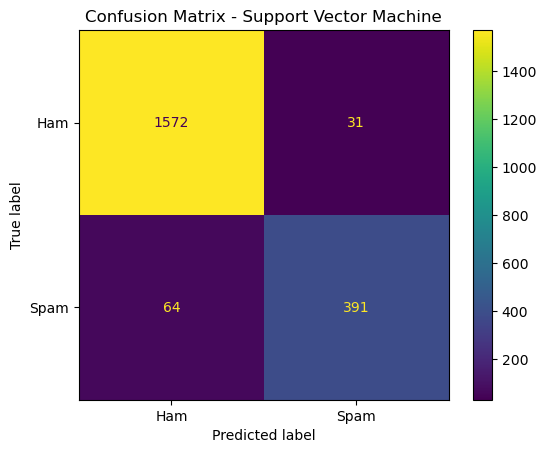

In [39]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()

plt.title("Confusion Matrix - Support Vector Machine")
plt.show()

In [41]:
def predict_sms(message):
    message_tfidf = tfidf.transform([message])
    prediction = best_model.predict(message_tfidf)[0]
    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"

message = input("Enter an SMS: ")
result = predict_sms(message)

print("\nInput SMS:", message)
print("Prediction:", result)


Input SMS: Congratulations! You won a free iPhone. Click now!
Prediction: SPAM


In [42]:
message = input("Enter an SMS: ")
result = predict_sms(message)

print("\nInput SMS:", message)
print("Prediction:", result)


Input SMS: Hey, I'll reach home around 7 PM. See you soon!
Prediction: HAM
